In [1]:
import numpy as np
import matplotlib.pyplot as plt

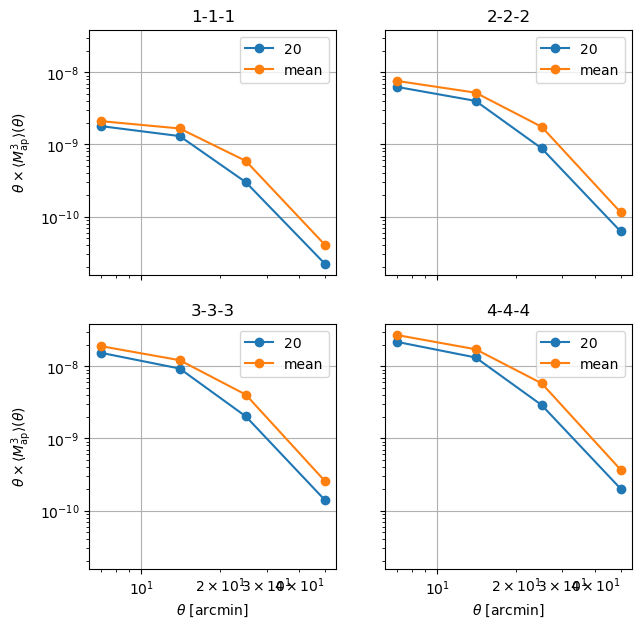

In [32]:
fig, axes = plt.subplots(2,2,figsize=(7,7), sharex=True, sharey=True)
axes = axes.flatten()
axes[0].set_yscale('log')
axes[0].set_xscale('log')

t = np.loadtxt('../output/2pt-plus-3pt-20/map3/filters.txt')[0]
for i in range(4):
    map3 = np.loadtxt('../output/2pt-plus-3pt-20/map3/map-bin_{0},bin_{0},bin_{0}.txt'.format(i+1))
    axes[i].plot(t, t*map3, marker='o', label='20')

    map3 = np.loadtxt('../output/2pt-plus-3pt-edge/map3/map-bin_{0},bin_{0},bin_{0}.txt'.format(i+1))
    axes[i].plot(t, t*map3, marker='o', label='mean')

    axes[i].grid()
    axes[i].set_title(f'{i+1}-{i+1}-{i+1}')
    axes[i].legend()

    if i % 2 == 0:
        axes[i].set_ylabel(r'$\theta \times \langle M_{\rm ap}^3\rangle(\theta)$')
    if i > 1:
        axes[i].set_xlabel(r'$\theta$ [arcmin]')

plt.show()

In [27]:
t = np.logspace(np.log10(0.5), np.log10(80.0), 20+1)[:-1]

In [28]:
t

array([ 0.5       ,  0.64443038,  0.83058102,  1.07050328,  1.37972966,
        1.77827941,  2.29195454,  2.95401025,  3.80730788,  4.9070897 ,
        6.32455532,  8.15147113, 10.50611122, 13.54091441, 17.45235314,
       22.49365301, 28.99118655, 37.36560252, 48.15905858, 62.0703205 ])

In [29]:
np.diff(np.log(t))

array([0.25375869, 0.25375869, 0.25375869, 0.25375869, 0.25375869,
       0.25375869, 0.25375869, 0.25375869, 0.25375869, 0.25375869,
       0.25375869, 0.25375869, 0.25375869, 0.25375869, 0.25375869,
       0.25375869, 0.25375869, 0.25375869, 0.25375869])

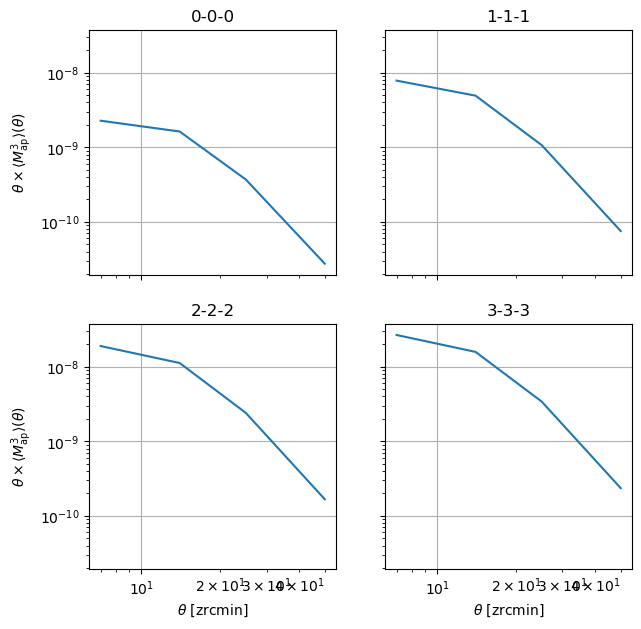

In [17]:
fig, axes = plt.subplots(2,2,figsize=(7,7), sharex=True, sharey=True)
axes = axes.flatten()
axes[0].set_yscale('log')
axes[0].set_xscale('log')

#t = np.loadtxt('../output/2pt-plus-3pt/map3/filters.txt')[0]
for i in range(4):
    map3 = np.loadtxt('../output/2pt-plus-3pt/map3/map-bin_{0},bin_{0},bin_{0}.txt'.format(i+1))
    axes[i].plot(t, t*map3)
    axes[i].grid()
    axes[i].set_title(f'{i}-{i}-{i}')

    if i % 2 == 0:
        axes[i].set_ylabel(r'$\theta \times \langle M_{\rm ap}^3\rangle(\theta)$')
    if i > 1:
        axes[i].set_xlabel(r'$\theta$ [zrcmin]')
plt.show()

In [16]:
# np.diff(np.log(np.logspace(np.log10(0.5), np.log10(80), 20)))
# np.diff(np.log(np.logspace(np.log10(0.5), np.log10(80), 20+1)))

array([0.25375869, 0.25375869, 0.25375869, 0.25375869, 0.25375869,
       0.25375869, 0.25375869, 0.25375869, 0.25375869, 0.25375869,
       0.25375869, 0.25375869, 0.25375869, 0.25375869, 0.25375869,
       0.25375869, 0.25375869, 0.25375869, 0.25375869, 0.25375869])

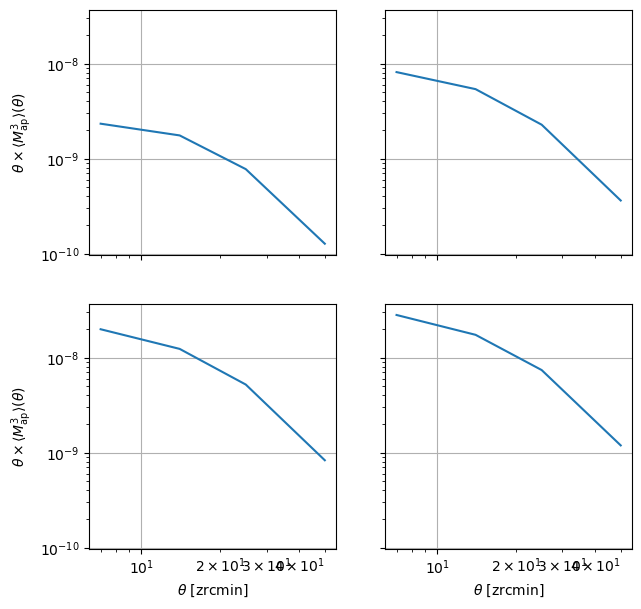

In [5]:
fig, axes = plt.subplots(2,2,figsize=(7,7), sharex=True, sharey=True)
axes = axes.flatten()
axes[0].set_yscale('log')
axes[0].set_xscale('log')

t = np.loadtxt('../output/2pt-plus-3pt/map3/filters.txt')[0]
for i in range(4):
    map3 = np.loadtxt('../output/2pt-plus-3pt/map3/map-bin_{0},bin_{0},bin_{0}.txt'.format(i+1))
    axes[i].plot(t, t*map3)
    axes[i].grid()

    if i % 2 == 0:
        axes[i].set_ylabel(r'$\theta \times \langle M_{\rm ap}^3\rangle(\theta)$')
    if i > 1:
        axes[i].set_xlabel(r'$\theta$ [zrcmin]')
plt.show()

In [50]:
import fastnc
from astropy.cosmology import wCDM

In [51]:
bs = fastnc.bispectrum.BispectrumHalofit()

setting a default source distribution: zs=[1, 2], pzs=[1, 1]


In [52]:
cosmo = wCDM(H0=100*0.673,\
            Om0=0.2599993452319742, \
            Ode0=1.0-0.2599993452319742, \
            meta = {'sigma8':0.6959206668889029, \
                    'n':0.9649})
bs.set_cosmology(cosmo)

In [53]:
nzbin = 4
bs.set_source_distribution(
    [np.loadtxt('../output/2pt-plus-3pt/nz_source/z.txt') for i in range(nzbin)],
    [np.loadtxt('../output/2pt-plus-3pt/nz_source/bin_{}.txt'.format(i+1)) for i in range(nzbin)],
    ['bin_%d' % (i+1) for i in range(nzbin)]
)
bs.compute_lensing_kernel()

In [54]:
bs.set_pklin(
    np.loadtxt('../output/2pt-plus-3pt/matter_power_lin/k_h.txt'),
    np.loadtxt('../output/2pt-plus-3pt/matter_power_lin/p_k.txt')[0,:]
)
# set lienar growth rate
bs.set_lgr(
    np.loadtxt('../output/2pt-plus-3pt/growth_parameters/z.txt'),
    np.loadtxt('../output/2pt-plus-3pt/growth_parameters/d_z.txt')
)

In [55]:

bs.interpolate()

In [56]:
def uhat(x):
    y = x**2/2
    return y*np.exp(-y)

In [57]:
ell1 = ell2 = np.logspace(np.log10(bs.ell12min), np.log10(bs.ell12max), 130)
vphi = np.linspace(np.arccos(bs.mumax), np.pi, 100)
ELL1, ELL2, VPHI = np.meshgrid(ell1, ell2, vphi, indexing='ij')
ELL1, ELL2, ELL3 = fastnc.trigutils.x1x2phi_to_x1x2x3(ELL1, ELL2, -VPHI)

In [58]:
def calc_map3(t, ELL1, ELL2, ELL3, BS, dlnell, dvphi):
    ELL1, ELL2, ELL3 = ELL1.ravel(), ELL2.ravel(), ELL3.ravel()
    x1 = np.outer(t, ELL1)
    x2 = np.outer(t, ELL2)
    x3 = np.outer(t, ELL3)
    w = uhat(x1) * uhat(x2) * uhat(x3) * ELL1**2*ELL2**2 * dlnell * dvphi
    return w.dot(BS.ravel()) * 2/(2*np.pi)**3

In [59]:
i = 3
BS = bs.kappa_bispectrum(ELL1, ELL2, ELL3, sample_combination=(f'bin_{i+1}', f'bin_{i+1}', f'bin_{i+1}'), method='interp')

In [60]:
map3_bf = calc_map3(np.deg2rad(t/60.0), ELL1, ELL2, ELL3, BS, np.diff(np.log(ell1))[0], np.diff(vphi)[0])
map3 = np.loadtxt('../output/2pt-plus-3pt/map3/map-bin_{0},bin_{0},bin_{0}.txt'.format(i+1))

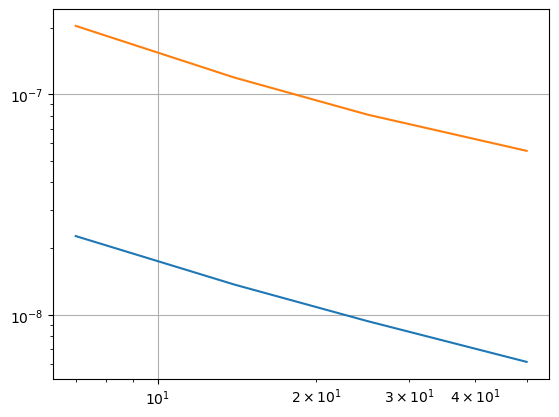

In [61]:
plt.figure()
plt.loglog(t, t*map3, label='nc')
plt.loglog(t, t*map3_bf, label='bf')
plt.grid()
plt.show()

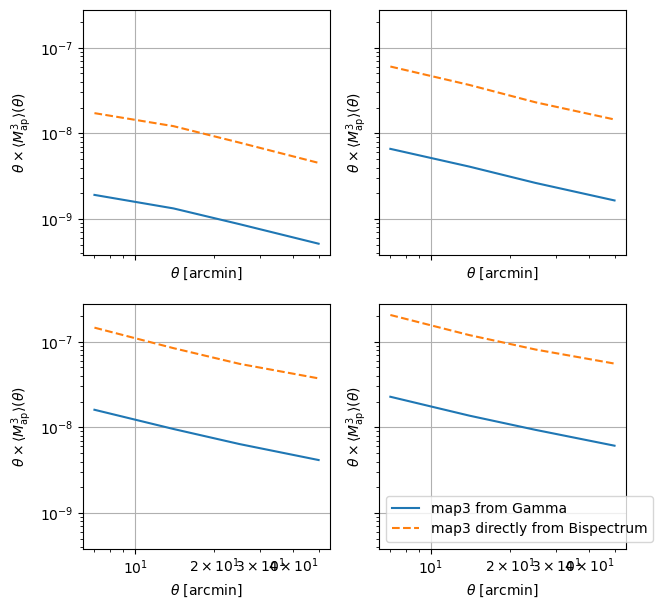

In [66]:
fig, axes = plt.subplots(2,2,figsize=(7,7), sharex=True, sharey=True)
axes = axes.flatten()
axes[0].set_yscale('log')
axes[0].set_xscale('log')

t = np.loadtxt('../output/2pt-plus-3pt/map3/filters.txt')[0]
for i in range(4):
    map3 = np.loadtxt('../output/2pt-plus-3pt/map3/map-bin_{0},bin_{0},bin_{0}.txt'.format(i+1))
    axes[i].plot(t, t*map3, label='map3 from Gamma')

    BS = bs.kappa_bispectrum(ELL1, ELL2, ELL3, sample_combination=(f'bin_{i+1}', f'bin_{i+1}', f'bin_{i+1}'), method='interp')
    map3_bf = calc_map3(np.deg2rad(t/60.0), ELL1, ELL2, ELL3, BS, np.diff(np.log(ell1))[0], np.diff(vphi)[0])
    axes[i].plot(t, t*map3_bf, ls='--', label='map3 directly from Bispectrum')

    axes[i].grid()
    axes[i].set_xlabel(r'$\theta$ [arcmin]')
    axes[i].set_ylabel(r'$\theta \times \langle M_{\rm ap}^3\rangle(\theta)$')
axes[-1].legend()
plt.show()

In [24]:
bs.halofit.get_sigma8z(0.0)

0.6959207466928193